# Chest X-ray Pneumonia Detection
## Exploratory Data Analysis

In [10]:
import pandas as pd

df = pd.read_csv("data/dataset.csv")
df.head()

,image_path,label
0,C:\Users\pc\Downloads\chest_xray\train\NORMAL\...,NORMAL
1,C:\Users\pc\Downloads\chest_xray\train\NORMAL\...,NORMAL
2,C:\Users\pc\Downloads\chest_xray\train\NORMAL\...,NORMAL
3,C:\Users\pc\Downloads\chest_xray\train\NORMAL\...,NORMAL
4,C:\Users\pc\Downloads\chest_xray\train\NORMAL\...,NORMAL


In [12]:
df["label"].value_counts()

label
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

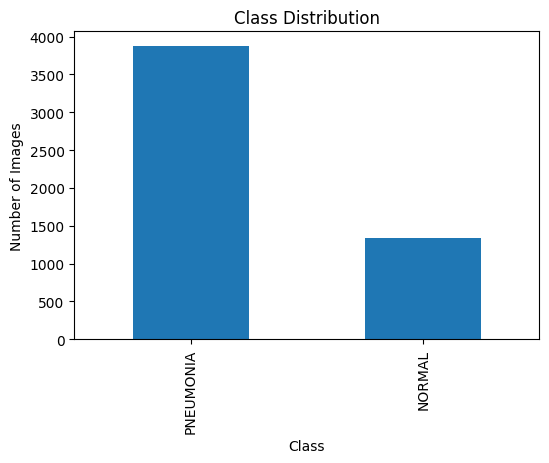

In [13]:
import matplotlib.pyplot as plt

counts = df["label"].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

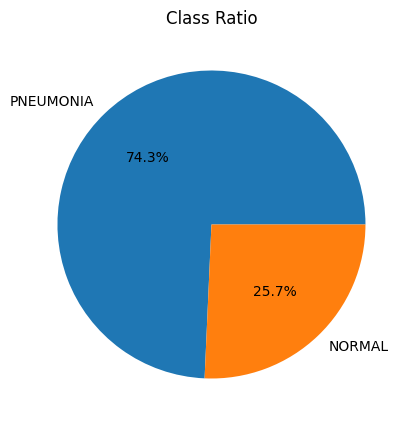

In [14]:
plt.figure(figsize=(5,5))
counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Class Ratio")
plt.ylabel("")
plt.show()

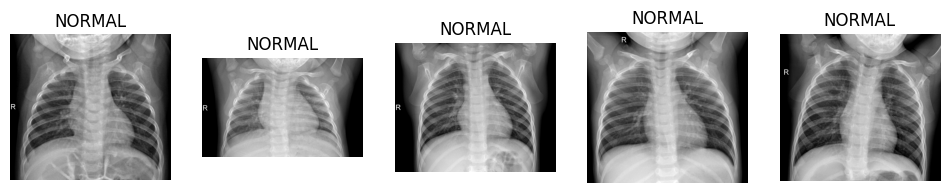

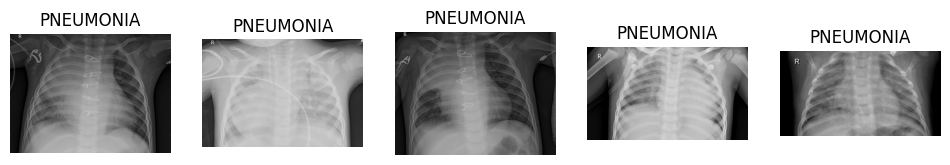

In [15]:
import cv2
import matplotlib.pyplot as plt

def show_samples(label, n=5):
    sample = df[df["label"] == label].sample(n)

    plt.figure(figsize=(12,3))

    for i, (_, row) in enumerate(sample.iterrows()):
        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(label)

    plt.show()

show_samples("NORMAL", 5)
show_samples("PNEUMONIA", 5)

In [16]:
from sklearn.model_selection import train_test_split

# تقسیم اول → Train + Test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# تقسیم دوم → Train + Validation
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3337
Validation: 835
Test: 1044


In [17]:
train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/val.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

print("✅ Files saved")

✅ Files saved
